# X-KGRank: Graph-RAG Framework for Explainable Recommendations
## Dataset  — Musical Instruments (Amazon Reviews 2023)

**CMPE 255 – Data Mining | San José State University**  
Team: Erick Vazquez · Jainish Patel · Meenakshi Rajpurohit



## Pipeline Overview

```
[1] Setup & Download       → Raw .jsonl + benchmark splits from HuggingFace
[2] EDA                    → Understand sparsity, cold-start, co-purchase density
[3] Neo4j Schema Prep      → Build node/edge tables for KG persistence


```


## Step 1 — Environment Setup & HuggingFace Authentication

Loads the HF token from Colab Secrets (never hardcoded), creates local data directories,
and defines a streaming download helper that pulls files in 1 MB chunks to avoid memory overflows.


In [ ]:
from google.colab import userdata
import os, requests

os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')
os.makedirs("/content/amazon_data", exist_ok=True)

HEADERS = {"Authorization": f"Bearer {os.environ['HF_TOKEN']}"}
BASE    = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main"

def hf_download(remote_path, local_name):
    url = f"{BASE}/{remote_path}"
    print(f"⬇ {remote_path}...")
    with requests.get(url, headers=HEADERS, stream=True) as r:
        r.raise_for_status()
        path = f"/content/amazon_data/{local_name}"
        with open(path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=1024*1024):
                f.write(chunk)
    size = os.path.getsize(path) / 1e6
    print(f"  ✅ {path} ({size:.1f} MB)")
    return path

print("✅ Setup complete")

✅ Setup complete


## Step 2 — Download Raw Data from HuggingFace

| File | Purpose |
|---|---|
| `Musical_Instruments.jsonl` | Raw user reviews (ratings, text, timestamps) |
| `meta_Musical_Instruments.jsonl` | Item metadata (title, price, co-purchase edges) |
| `train / valid / test .csv` | Pre-built 5-core leave-one-out benchmark splits |
| `asin2category.json` | ASIN → category mapping |

**Why 5-core?** Filters to users and items with ≥5 interactions — cleaner signal,
directly comparable to published RecSys baselines (LightGCN, KGAT etc.).


In [ ]:
review_path = hf_download("raw/review_categories/Musical_Instruments.jsonl", "reviews.jsonl")
meta_path   = hf_download("raw/meta_categories/meta_Musical_Instruments.jsonl",  "meta.jsonl")

hf_download("benchmark/5core/last_out/Musical_Instruments.train.csv", "train.csv")
hf_download("benchmark/5core/last_out/Musical_Instruments.valid.csv", "valid.csv")
hf_download("benchmark/5core/last_out/Musical_Instruments.test.csv",  "test.csv")
hf_download("asin2category.json", "asin2category.json")

⬇ raw/review_categories/Musical_Instruments.jsonl...
  ✅ /content/amazon_data/reviews.jsonl (1557.8 MB)
⬇ raw/meta_categories/meta_Musical_Instruments.jsonl...
  ✅ /content/amazon_data/meta.jsonl (631.9 MB)
⬇ benchmark/5core/last_out/Musical_Instruments.train.csv...
  ✅ /content/amazon_data/train.csv (23.0 MB)
⬇ benchmark/5core/last_out/Musical_Instruments.valid.csv...
  ✅ /content/amazon_data/valid.csv (3.3 MB)
⬇ benchmark/5core/last_out/Musical_Instruments.test.csv...
  ✅ /content/amazon_data/test.csv (3.3 MB)
⬇ asin2category.json...
  ✅ /content/amazon_data/asin2category.json (1246.8 MB)


'/content/amazon_data/asin2category.json'

## Step 3 — Load Data into Pandas

Parses `.jsonl` files line-by-line (safe for large files) into DataFrames.
The benchmark CSVs define our evaluation protocol — `df_test` is the held-out ground truth.

> `df_reviews` = full raw corpus. `df_train/valid/test` = 5-core filtered benchmark splits.


In [ ]:
import pandas as pd, json

def read_jsonl(path):
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

df_reviews = read_jsonl(review_path)
df_meta    = read_jsonl(meta_path)
df_train   = pd.read_csv("/content/amazon_data/train.csv")
df_valid   = pd.read_csv("/content/amazon_data/valid.csv")
df_test    = pd.read_csv("/content/amazon_data/test.csv")

# Normalize column names (benchmark CSVs use different names)
def normalize_columns(df):
    col_map = {'reviewerID':'user_id','asin':'parent_asin',
                'overall':'rating','unixReviewTime':'timestamp'}
    return df.rename(columns={k:v for k,v in col_map.items() if k in df.columns})

df_train = normalize_columns(df_train)
df_valid = normalize_columns(df_valid)
df_test  = normalize_columns(df_test)

print(f"Reviews:  {df_reviews.shape}")
print(f"Meta:     {df_meta.shape}")
print(f"Train:    {df_train.shape}")
print(f"Valid:    {df_valid.shape}")
print(f"Test:     {df_test.shape}")
print("\nReview columns:", df_reviews.columns.tolist())
print("Meta columns:  ", df_meta.columns.tolist())
print("Train columns: ", df_train.columns.tolist())

Reviews:  (3017439, 10)
Meta:     (213593, 16)
Train:    (396958, 4)
Valid:    (57439, 4)
Test:     (57439, 4)

Review columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
Meta columns:   ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author']
Train columns:  ['user_id', 'parent_asin', 'rating', 'timestamp']


## Step 4 — Exploratory Data Analysis (EDA)

Four visualizations that directly motivate X-KGRank design choices:

- **Rating distribution** → positivity bias (skewed toward 4–5 stars)
- **Reviews per year** → data growth trend and freshness
- **Cold-start stats** → high sparsity justifies KG augmentation
- **Co-purchase density** → item-item edge richness for KG construction

> **Key finding:** avg ~1.7 reviews/user and 1.67M cold-start users confirm that
> standard collaborative filtering will fail — KG path signals are essential.


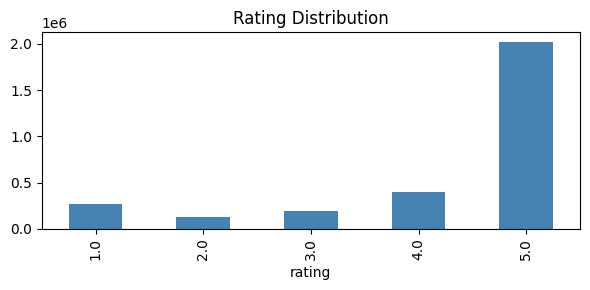

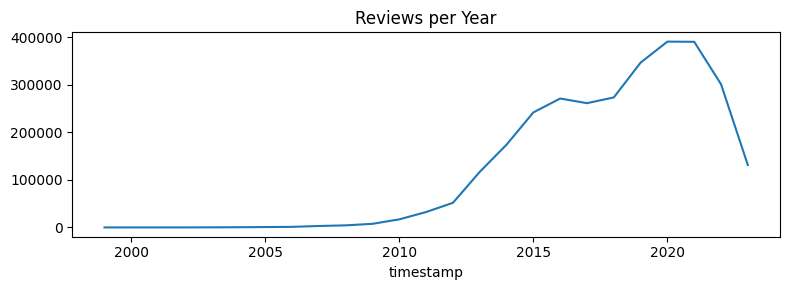

=== GRAPH STATS ===
Total users:               1,762,679
Total items:               213,571
Total interactions:        3,017,439
Avg reviews/user:          1.71
Avg reviews/item:          14.13
Cold-start users (<5):     1,678,105
Cold items (< median=2): 78,649
Popularity threshold p=50%: 2.0

=== CO-PURCHASE EDGES ===
Items with edges: 0 / 213,593 (0.0%)
count    213593.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: cp_count, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

# 1. Rating distribution
df_reviews['rating'].value_counts().sort_index().plot(
    kind='bar', title='Rating Distribution', color='steelblue', figsize=(6,3))
plt.tight_layout(); plt.show()

# 2. Reviews per year
df_reviews['timestamp'] = pd.to_datetime(df_reviews['timestamp'], unit='ms', errors='coerce')
df_reviews.groupby(df_reviews['timestamp'].dt.year).size().plot(
    title='Reviews per Year', figsize=(8,3))
plt.tight_layout(); plt.show()

# 3. User & item stats
user_counts   = df_reviews['user_id'].value_counts()
item_counts   = df_reviews['parent_asin'].value_counts()
pop_threshold = item_counts.median()

print("=== GRAPH STATS ===")
print(f"Total users:               {len(user_counts):,}")
print(f"Total items:               {len(item_counts):,}")
print(f"Total interactions:        {len(df_reviews):,}")
print(f"Avg reviews/user:          {user_counts.mean():.2f}")
print(f"Avg reviews/item:          {item_counts.mean():.2f}")
print(f"Cold-start users (<5):     {(user_counts < 5).sum():,}")
print(f"Cold items (< median={pop_threshold:.0f}): {(item_counts < pop_threshold).sum():,}")
print(f"Popularity threshold p=50%: {pop_threshold}")

# 4. Co-purchase density
df_meta['cp_count'] = df_meta['bought_together'].apply(
    lambda x: len(x) if isinstance(x, list) else 0)
items_with_cp = (df_meta['cp_count'] > 0).sum()
print(f"\n=== CO-PURCHASE EDGES ===")
print(f"Items with edges: {items_with_cp:,} / {len(df_meta):,} ({100*items_with_cp/len(df_meta):.1f}%)")
print(df_meta['cp_count'].describe())

## Step 5 — Build Neo4j-Ready Node & Edge Tables

Maps raw data to the Neo4j graph schema:

```
(User)-[:REVIEWED {rating}]->(Item)
(Item)-[:CO_PURCHASED]->(Item)
```

`is_cold` flag (popularity < median) drives the **popularity-selective LLM re-ranker**:
only cold items get expensive KG subgraph retrieval at inference time (p=50% threshold,
following K-RagRec Wang et al. 2025).


In [ ]:
# USER NODES
user_nodes = pd.DataFrame({
    'nodeId': df_reviews['user_id'].unique(),
    'label':  'User',
    'review_count': df_reviews.groupby('user_id').size().values
})

# ITEM NODES
item_meta_cols = [c for c in ['parent_asin','title','price','average_rating','rating_number']
                  if c in df_meta.columns]
item_nodes = df_meta[item_meta_cols].drop_duplicates('parent_asin')    .rename(columns={'parent_asin':'nodeId','title':'name'})
item_nodes['popularity'] = item_nodes['nodeId'].map(item_counts).fillna(0).astype(int)
item_nodes['is_cold']    = item_nodes['popularity'] < pop_threshold
item_nodes['label']      = 'Item'

# REVIEWED EDGES
reviewed_edges = df_reviews[['user_id','parent_asin','rating','timestamp','verified_purchase']]    .drop_duplicates(['user_id','parent_asin'])    .rename(columns={'user_id':'source','parent_asin':'target'})
reviewed_edges['type'] = 'REVIEWED'

# CO_PURCHASED EDGES
co_edges = df_meta[df_meta['cp_count'] > 0][['parent_asin','bought_together']]    .explode('bought_together').dropna(subset=['bought_together'])    .rename(columns={'parent_asin':'source','bought_together':'target'})
co_edges = co_edges[co_edges['source'] != co_edges['target']]
co_edges['type'] = 'CO_PURCHASED'

print(f"User nodes:        {len(user_nodes):,}")
print(f"Item nodes:        {len(item_nodes):,}")
print(f"REVIEWED edges:    {len(reviewed_edges):,}")
print(f"CO_PURCHASED:      {len(co_edges):,}")
print(f"Graph density:     {len(reviewed_edges)/(len(user_nodes)*len(item_nodes)):.8f}")

User nodes:        1,762,679
Item nodes:        213,593
REVIEWED edges:    2,975,551
CO_PURCHASED:      0
Graph density:     0.00000790
